<a href="https://colab.research.google.com/github/jskameni/Sentiments_Analysis_YouTube_Cameroon/blob/main/Analyse_des_sentiments_Cameroun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching Comments for video: auLURoidqt0
Fetching Comments for video: WVIxdjYlAfA
Fetching Comments for video: PTDHZWMdQEo
Fetching Comments for video: 6XSH4siI41E
Fetching Comments for video: SAtqvhwv-28
Fetching Comments for video: wB_unMaM9gU
Fetching Comments for video: sQMviGMxjsw
Fetching Comments for video: TsNGmzPjjgk
Fetching Comments for video: TDVkQ8Bp0fE
Fetching Comments for video: iGdHPt7MGi8
Fetching Comments for video: auVN-TDIkMs
Fetching Comments for video: 5fJuR8tj9cA
Fetching Comments for video: lXb28xFGNB8
Fetching Comments for video: GFj-E6cHzo4
Fetching Comments for video: BNWjAfknUDw
Fetching Comments for video: U0C6ebdooaM
Fetching Comments for video: ypNCj3EHUDU
Fetching Comments for video: ugKVzfwPxJI
Fetching Comments for video: JyqqiB-w8t0
Fetching Comments for video: Gnj3I8rzfUA
Fetching Comments for video: 1HzNgF4kenQ
Fetching Comments for video: EHBGrv6zlv0
Fetching Comments for video: KoPcctwd7zA
Fetching Comments for video: 94H6Q9eclDI
Fetching Comment

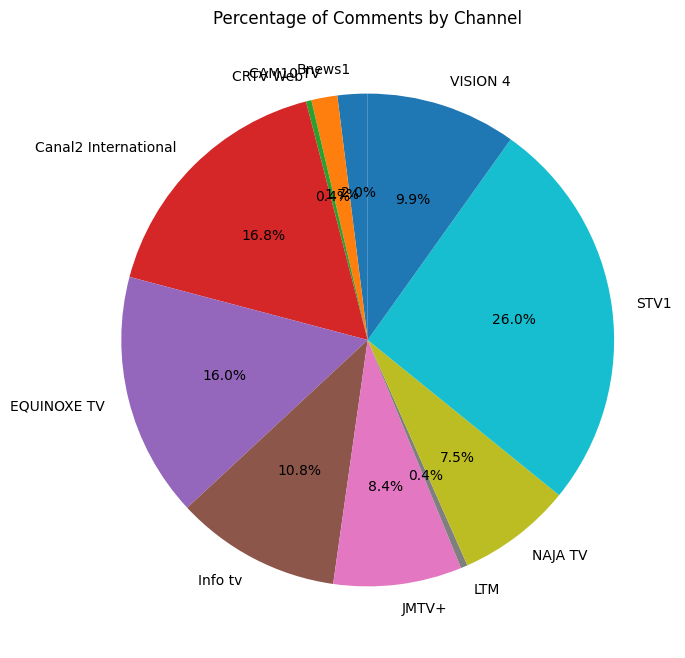

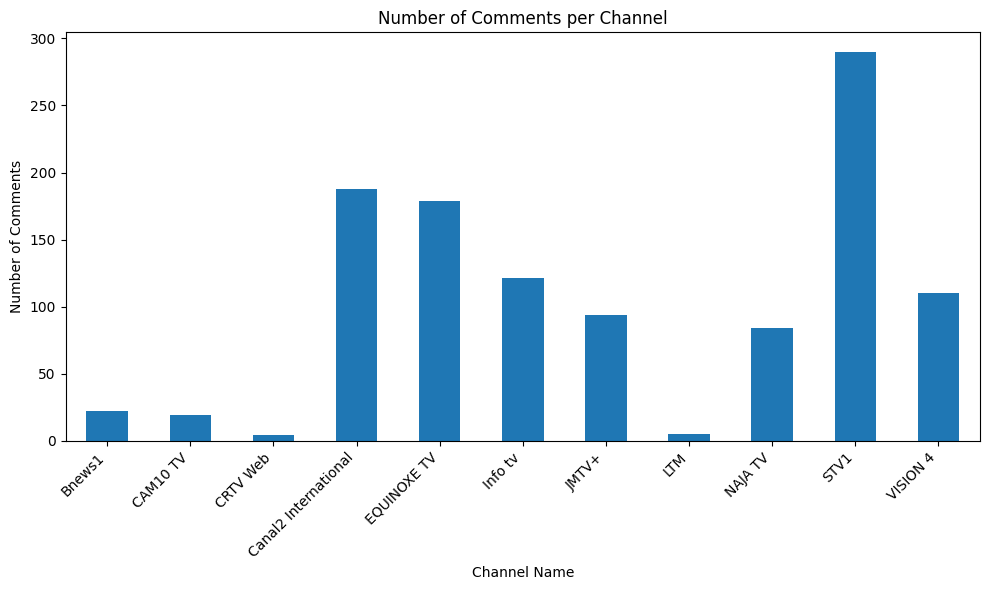

In [ ]:
# Install necessary libraries (if not already installed)
!pip install emoji
!pip install vaderSentiment-fr
!pip install google-api-python-client

from googleapiclient.discovery import build
import re
import emoji
from vaderSentiment_fr.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta


# Replace with your actual API key
API_KEY = 'Your_api_key' # Put in your API Key

youtube = build('youtube', 'v3', developerKey=API_KEY)

# Load channel data
try:
  df_channels = pd.read_csv('CameroonNewsChannels.csv')
except FileNotFoundError:
  print("Error: CameroonNewsChannels.csv not found.")
  exit()


def get_comments_for_video(video_id, uploader_channel_id, channel_name):
    print(f"Fetching Comments for video: {video_id}")
    comments_data = []
    nextPageToken = None
    while True:
        request = youtube.commentThreads().list(
            part='snippet',
            videoId=video_id,
            maxResults=100,
            pageToken=nextPageToken
        )
        try:
            response = request.execute()
        except Exception as e:
            print(f"Error fetching comments for {video_id}: {e}")
            return []  # Return an empty list in case of error
        for item in response['items']:
            comment = item['snippet']['topLevelComment']['snippet']
            if comment['authorChannelId']['value'] != uploader_channel_id:
                comments_data.append([channel_id, channel_name, comment['textDisplay']])
        nextPageToken = response.get('nextPageToken')
        if not nextPageToken:
            break
    return comments_data

# Calculate the date 8 days ago
three_days_ago = (datetime.now() - timedelta(days=8)).strftime('%Y-%m-%dT%H:%M:%SZ')

all_comments = []
for index, row in df_channels.iterrows():
    channel_id = row['Channel_Id']
    channel_name = row['Channel_Name']

    request = youtube.search().list(
        part="snippet",
        channelId=channel_id,
        maxResults=50, # Adjust as needed
        publishedAfter=three_days_ago,
        type="video"
    )

    response = request.execute()

    for item in response.get("items", []):
        video_id = item["id"]["videoId"]
        uploader_id = item['snippet']['channelId']  # Get uploader's channel ID
        comments = get_comments_for_video(video_id, uploader_id, channel_name)
        all_comments.extend(comments)



print(all_comments)

# Create a DataFrame
df_all_comments = pd.DataFrame(all_comments, columns=['Channel_Id', 'Channel_Name', 'Comment'])

# Pie chart of comment percentage by channel name
channel_comment_counts = df_all_comments.groupby('Channel_Name')['Comment'].count()
plt.figure(figsize=(10, 8))
plt.pie(channel_comment_counts, labels=channel_comment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Comments by Channel')
plt.show()

# Bar chart of comment counts by channel name
plt.figure(figsize=(10, 6))
channel_comment_counts.plot(kind='bar')
plt.xlabel('Channel Name')
plt.ylabel('Number of Comments')
plt.title('Number of Comments per Channel')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()






In [ ]:
import re

def traduire_argot_en_francais(texte):
    correspondances = {
        "répé": "Âgé", "rémé": "Âgé",
        "ya mo": "Aimer",
        "bro": "Ami", "combi": "Ami", "tatat": "Ami", "ndolè": "Ami", "pot": "Ami",
        "nkap": "Argent",
        "mouv le mouna": "Avorter",
        "niass": "Baiser", "fom": "Baiser", "mbinda": "Baiser",
        "ndamba": "Ballon", "guyo": "Ballon", "guio": "Ballon",
        "nak": "Battre", "basta": "Battre",
        "mô": "Belle", "mo": "Belle", "zouk-miel": "Belle",
        "wat": "Blanc",
        "tongô": "Boire", "jong": "Boisson",
        "yo": "Bonjour", "hao": "Bonjour",
        "motto": "Caca",
        "ngop": "Chaussure", "shouz": "Chaussure", "tchaka": "Chaussure",
        "nkouandjang": "Chien", "dagobert": "Chien",
        "nkunkuma": "Chef",
        "fala": "Chercher",
        "ndji-ndja": "Compliqué", "ntanga": "Compliqué",
        "babana": "Conducteur de moto",
        "shiba": "Descendre", "grap": "Descendre",
        "djoss": "Dire", "tok": "Dire", "toppo": "Dire",
        "chou": "Donner", "tchoko": "Donner",
        "nang": "Dormir",
        "thra": "Draguer", "topor": "Draguer",
        "banga": "Drogue", "gué": "Drogue", "kior": "Drogue", "njap": "Drogue", "lope": "Drogue",
        "ya": "Écouter",
        "bélè": "Enceinte",
        "muna": "Enfant", "mouna": "Enfant",
        "hamboc": "Ennuyer", "hambock": "Ennuyer",
        "pédé": "Efféminé", "ndepso": "Efféminé", "tchèlè": "Efféminé",
        "mbenguiste": "Étranger vivant en occident",
        "mimba": "Être prétentieux",
        "fom": "Faire l'amour", "niass": "Faire l'amour", "kinkonser": "Faire l'amour", "nack mbit": "Faire l'amour", "kombo": "Faire l'amour",
        "mifa": "Famille",
        "lass": "Fesses",
        "ndjoka": "Fête",
        "wé": "Fille", "nga": "Fille",
        "bolè": "Finir",
        "réfré": "Frère", "tara": "Frère",
        "ndambaman": "Footballeur",
        "njoh": "Gratuit",
        "ngomna": "Gouvernement",
        "boum la": "Gronder", "vecto": "Gronder", "brass": "Gronder",
        "ndock": "Gourmand",
        "feyman": "Homme d'affaire malhonnète",
        "hot": "Insulte", "kosh": "Insulte", "cosh": "Insulte",
        "piol": "Maison",
        "tchop": "Manger", "damé": "Manger", "nyama": "Nourriture",
        "waka": "Marcher", "djonny": "Marcher", "dangoua": "Marcher",
        "bahat": "Mauvais coeur",
        "lom": "Mentir",
        "nyè": "Militaire", "mbéré": "Militaire",
        "beta": "Mieux",
        "molla": "Mon ami",
        "chimèn": "Odeur", "noumba": "Odeur (sentir mauvais)",
        "bombo": "Homonyme",
        "abeg": "Pardon", "abeck": "Pardon", "abec": "Pardon",
        "mboa": "Pays Natal",
        "mbeng": "Pays occidental",
        "tara": "Personne",
        "ré": "Position",
        "ngass": "Prison", "ngata": "Prison",
        "maata": "Problème", "blem": "Problème", "mata": "Problème",
        "mbock": "Prostituée",
        "choua": "Prendre", "tcha": "Prendre",
        "clash": "Querelles",
        "kwatt": "Quartier",
        "bohboh": "Riche", "tehteh": "Riche", "tété": "Riche",
        "fimba": "Ressembler à",
        "briss": "Réussir", "bris": "Réussir",
        "lolo": "Seins",
        "wanda": "S'étonner",
        "comot": "Sortir",
        "réssé": "Soeur",
        "moukouagne": "Sorcellerie", "famla": "Sorcellerie",
        "nian": "Trahir", "niang": "Trahir",
        "wok": "Travail",
        "popoh": "Vrai",
    }

    def remplacer(match):
        mot = match.group(0).lower()
        if mot in correspondances:
            print(f"Correspondance trouvée: {mot} -> {correspondances[mot]}")
        return correspondances.get(mot, match.group(0))

    pattern = re.compile(r'\b(' + '|'.join(re.escape(mot) for mot in correspondances.keys()) + r')\b', re.IGNORECASE)
    texte_traduit = pattern.sub(remplacer, texte)

    return texte_traduit

# Exemple d'utilisation
texte_exemple = "Yo Bro, on va tchop et boire du Tongô après le Wok."
traduction = traduire_argot_en_francais(texte_exemple)
print(traduction)


Correspondance trouvée: yo -> Bonjour
Correspondance trouvée: bro -> Ami
Correspondance trouvée: tchop -> Manger
Correspondance trouvée: tongô -> Boire
Correspondance trouvée: wok -> Travail
Bonjour Ami, on va Manger et boire du Boire après le Travail.


In [ ]:
hyperlink_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
threshold_ratio = 0.65
relevant_comments = []

# Assuming all_comments is a list of lists, where each inner list has 3 elements
# and the comment text is the third element.

for comment_data in all_comments:
    try:
        comment_text = comment_data[2].lower().strip()
    except IndexError:
        #print(f"Skipping invalid comment data: {comment_data}")
        continue

    emojis = emoji.emoji_count(comment_text)
    text_characters = len(re.sub(r'\s', '', comment_text))

    if (any(char.isalnum() for char in comment_text)) and not hyperlink_pattern.search(comment_text):
        if emojis == 0 or (text_characters / (text_characters + emojis)) > threshold_ratio:
            relevant_comments.append(traduire_argot_en_francais(comment_text)) # Append the entire comment data
print(relevant_comments)


Correspondance trouvée: mo -> Belle
Correspondance trouvée: bro -> Ami
Correspondance trouvée: ya -> Écouter
Correspondance trouvée: njoh -> Gratuit
Correspondance trouvée: ya -> Écouter
Correspondance trouvée: banga -> Drogue
Correspondance trouvée: ya -> Écouter
Correspondance trouvée: ya -> Écouter
Correspondance trouvée: wanda -> S'étonner
Correspondance trouvée: ndolè -> Ami
Correspondance trouvée: ndolè -> Ami
Correspondance trouvée: muna -> Enfant
Correspondance trouvée: bro -> Ami
Correspondance trouvée: ya -> Écouter
Correspondance trouvée: ya -> Écouter
['regardez yaoundé leur capitale!', 'merci beaucoup monsieur le ministre...nous allons refaire jusqu&#39;à ce que nous intégrons la fonction publique...car actuellement ça ne va pas.👏👏👏', 'au lieu de nous poster les vidéos qui s&#39;entrecoupent, vaut mieux laisser. améliorer la qualité de vos directs et replay .', 'seigneur  le ministre  des travaux  public  doits  néttoyer  les routes ????', 'qui va a la retraite au cameroun

In [ ]:
f = open("ytcomments.txt", 'w', encoding='utf-8')
for idx, comment in enumerate(relevant_comments):
    f.write(str(comment)+"\n")
f.close()
print("Comments stored successfully!")

Comments stored successfully!


In [ ]:
def sentiment_scores(comment, polarity):

  # Creating a SentimentIntensityAnalyzer object.
  sentiment_object = SentimentIntensityAnalyzer()

  sentiment_dict = sentiment_object.polarity_scores(comment)
  polarity.append(sentiment_dict['compound'])
  print(sentiment_dict)

  return polarity


polarity = []
positive_comments = []
negative_comments = []
neutral_comments = []

f = open("ytcomments.txt", 'r', encoding='`utf-8')
print("Reading Comments...")
comments = f.readlines()
f.close()
print("Analysing Comments...")
for index, items in enumerate(comments):
    polarity = sentiment_scores(items, polarity)


    if polarity[-1] > 0.05:
        positive_comments.append(items)
    elif polarity[-1] < -0.05:
        negative_comments.append(items)
    else:
        neutral_comments.append(items)

print(polarity)

Reading Comments...
Analysing Comments...
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': -0.0377}
{'neg': 0.0, 'neu': 0.868, 'pos': 0.132, 'compound': 0.5171}
{'neg': 0.0, 'neu': 0.717, 'pos': 0.283, 'compound': 0.7269}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': -0.123}
{'neg': 0.0, 'neu': 0.762, 'pos': 0.238, 'compound': 0.4588}
{'neg': 1.0, 'neu': 0.0, 'pos': 0.0, 'compound': -0.1779}
{'neg': 0.219, 'neu': 0.538, 'pos': 0.242, 'compound': 0.1531}
{'neg': 0.0, 'neu': 0.753, 'pos': 0.247, 'compound': 0.7836}
{'neg': 0.0, 'neu': 0.903, 'pos': 0.097, 'compound': 0.128}
{'neg': 0.302, 'neu': 0.364, 'pos': 0.334, 'compound': 0.34}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': -0.0271}
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': -0.0271}
{'neg': 0.0, 'neu': 0.854, 'pos': 0.146, 'compound': 0.1803}
{'neg': 0.0, 'neu': 0.876, 'pos': 0.124, 'compound': 0.1779}
{'neg': 0.0, 'neu': 0.902, 'pos': 0.098, 'compound': 0.0516}
{'neg': 0.095, 'neu': 0.875, 'pos': 0.031, 'compound': -0.

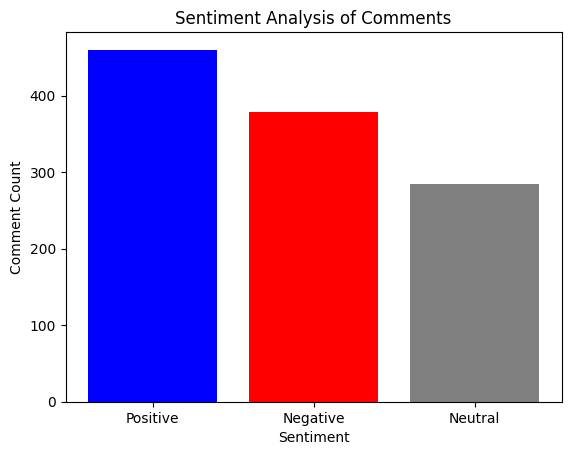

In [ ]:
positive_count = len(positive_comments)
negative_count = len(negative_comments)
neutral_count = len(neutral_comments)

# labels and data for Bar chart
labels = ['Positive', 'Negative', 'Neutral']
comment_counts = [positive_count, negative_count, neutral_count]

# Creating bar chart
plt.bar(labels, comment_counts, color=['blue', 'red', 'grey'])

# Adding labels and title to the plot
plt.xlabel('Sentiment')
plt.ylabel('Comment Count')
plt.title('Sentiment Analysis of Comments')

# Displaying the chart
plt.show()

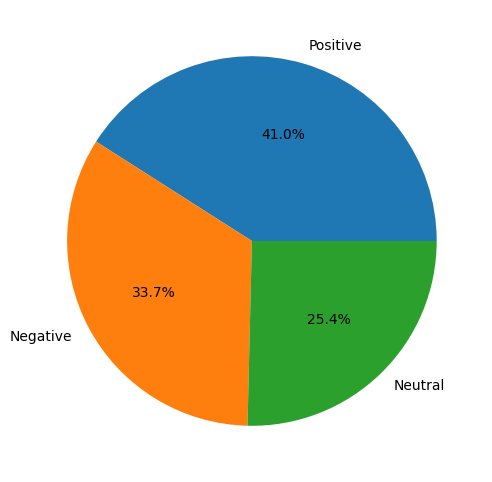

In [ ]:
# labels and data for Bar chart
labels = ['Positive', 'Negative', 'Neutral']
comment_counts = [positive_count, negative_count, neutral_count]

plt.figure(figsize=(10, 6)) # setting size

# plotting pie chart
#plt.pie(comment_counts, labels=labels)
plt.pie(comment_counts, labels=labels, autopct='%1.1f%%')

# Displaying Pie Chart
plt.show()